In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import joblib

# Styling
sns.set(style="darkgrid")

Load Dataset

In [ ]:
df = pd.read_csv("../data/heart.csv")
df.head()

In [ ]:
df.info()


In [ ]:
df.describe()

Target distribution

In [ ]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

Correlation Heatmap

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_scaled, y_train)

Predict (RF)

In [ ]:
rf_pred = rf_model.predict(X_test_scaled)

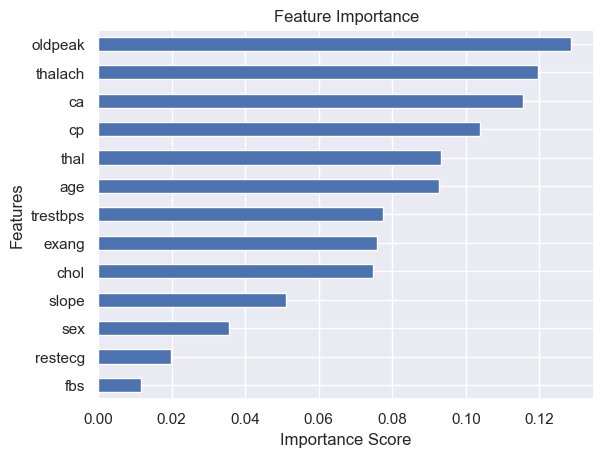

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

Evaluate (RF)

In [26]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8360655737704918

Confusion Matrix:
[[24  5]
 [ 5 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [25]:
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings("ignore")

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

from sklearn.metrics import accuracy_score
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.8852459016393442
